In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

In [2]:
# CONFIG
CSV_PATH = "Ibehej.csv"
TIMESTAMP_COL = "TimeStamp"
VALUE_COL = "P_HOME"

In [90]:
# FIX DATA
# Load CSV
df = pd.read_csv(CSV_PATH, sep=";")

df[TIMESTAMP_COL] = pd.to_datetime(df[TIMESTAMP_COL])

# Set time index
df = df.set_index(TIMESTAMP_COL)

df["P_HOME"] = np.where(
    df["P_HOME"] == 0,
    df["P_PV"] - df["P_GRID"] + df["P_BAT"],
    df["P_HOME"]                       
)

df["P_HOME"] = df["P_HOME"] + df["P_BAT"]
df[VALUE_COL] = df[VALUE_COL].abs()



# Resample
df = df.resample("h").mean()

df = df.fillna(df.shift(24))

df = df.interpolate("time").ffill().bfill()

# df = df.sort_index()
# dt = df.index.to_series().diff().dt.total_seconds() / 3600
# df["energy"] = df[VALUE_COL] * dt

df.index.name = TIMESTAMP_COL
df.to_csv("data_updated.csv", sep=";")


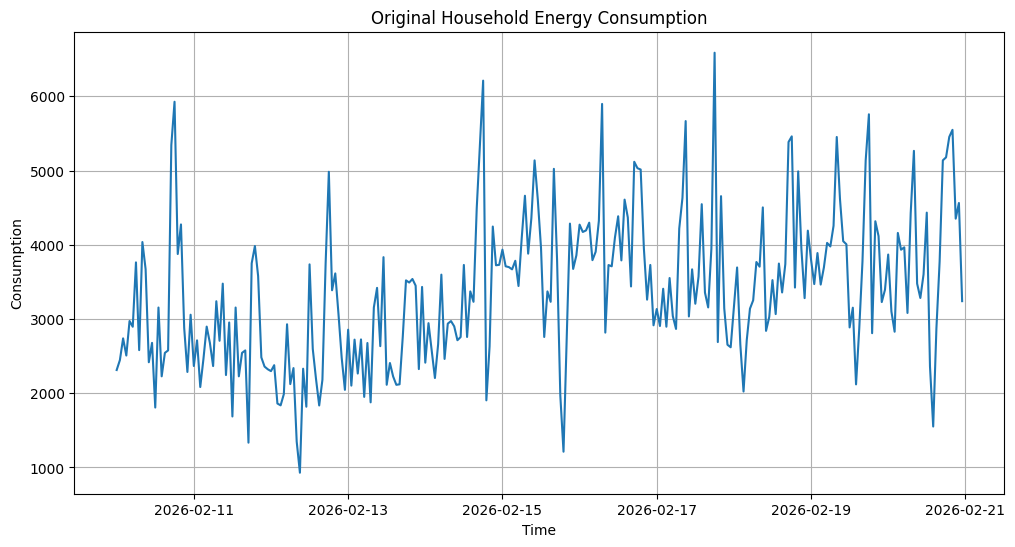

In [92]:
#### -----------------------------
# Plot original data
# -----------------------------

df = pd.read_csv("data_updated.csv", sep=";")
df[TIMESTAMP_COL] = pd.to_datetime(df[TIMESTAMP_COL])
df = df.set_index(TIMESTAMP_COL)

plt.figure(figsize=(12,6))

trimdf = df.loc["2026-02-10":"2026-02-20"].copy()

plt.plot(trimdf.index, trimdf[VALUE_COL])
# plt.plot(trimdf.index, trimdf["P_BAT"])
# plt.plot(trimdf.index, trimdf["P_GRID"])
# plt.plot(trimdf.index, trimdf["P_PV"])
# plt.plot(trimdf.index, trimdf["GRID_LIMIT"])
# plt.plot(trimdf.index, trimdf["energy"])
# plt.plot(trimdf.index, trimdf["energy_Wh"])



plt.title("Original Household Energy Consumption")
plt.xlabel("Time")
plt.ylabel("Consumption")
plt.grid(True)

# plt.figure(figsize=(12,6))
# plt.plot(trimdf.index, trimdf["temperature"])


plt.show()

In [69]:
df.loc["2026-02-11 11:00:00": "2026-02-11 20:00:00"]

,ID_zaznamu,ID_ZDROJE,SoC,P_PV,P_HOME,P_HOME_L1,P_HOME_L2,P_HOME_L3,P_EPS,P_GRID,...,FromBAT,FromBAT_T,SELL,SELL_T,BUY,BUY_T,Consumed,Consumed_T,GRID_LIMIT,energy
TimeStamp,,,,,,,,,,,,,,,,,,,,,
2026-02-11 11:00:00,186262,5,34.767,659.633,4294.634,577.300,621.567,615.400,0.0,0.300,...,5.890,5073.990,0.010,2709.350,24.870,20087.150,24.603,28376.543,NaN,1073.65850
2026-02-11 11:15:00,186269,5,28.548,626.968,1640.548,206.903,212.387,333.968,0.0,5.323,...,6.368,5074.468,0.019,2709.359,24.870,20087.150,25.232,28377.175,NaN,410.13700
2026-02-11 11:30:00,186276,5,27.500,736.167,1266.033,80.633,194.567,228.300,0.0,6.533,...,6.477,5074.577,0.020,2709.360,24.876,20087.156,25.453,28377.393,NaN,316.50825
2026-02-11 11:45:00,186283,5,22.800,785.733,4609.333,631.333,654.767,898.700,0.0,-1073.567,...,6.970,5075.070,0.020,2709.360,24.901,20087.181,26.128,28378.068,NaN,1152.33325
2026-02-11 12:00:00,186290,5,20.000,1780.214,3347.785,605.821,1206.714,1550.286,0.0,-3009.750,...,7.200,5075.300,0.020,2709.360,25.528,20087.807,27.301,28379.244,NaN,836.94625
2026-02-11 12:15:00,186297,5,20.500,1379.167,25.000,95.333,104.000,200.000,0.0,0.000,...,7.200,5075.300,0.020,2709.360,25.850,20088.130,27.880,28379.820,NaN,6.25000
2026-02-11 17:45:00,186393,5,19.000,0.000,1333.500,283.750,329.500,710.750,0.0,-1142.000,...,7.300,5075.400,0.020,2709.360,40.480,20102.758,44.560,28396.497,NaN,7334.25000
2026-02-11 18:00:00,186398,5,19.833,0.233,1562.000,521.300,606.033,871.433,0.0,-1749.167,...,7.300,5075.400,0.020,2709.360,40.742,20103.021,44.695,28396.634,NaN,390.50000
2026-02-11 18:15:00,186405,5,20.000,0.000,5750.903,1372.194,1283.226,3095.484,0.0,-5665.710,...,7.300,5075.400,0.020,2709.360,41.578,20103.854,45.458,28397.394,NaN,1437.72575


In [93]:
start = df.index.min().strftime("%Y-%m-%d")
end = df.index.max().strftime("%Y-%m-%d")

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude=50.793"
    f"&longitude=15.138"
    f"&start_date={start}"
    f"&end_date={end}"
    f"&hourly=temperature_2m,surface_pressure,precipitation,wind_speed_10m"
    f"&timezone=auto"
)

response = requests.get(url)
data = response.json()

# Convert API data to dataframe
temp_df = pd.DataFrame({
    "timestamp": data["hourly"]["time"],
    "temperature": data["hourly"]["temperature_2m"],
    "wind_speed": data["hourly"]["wind_speed_10m"],
    "pressure": data["hourly"]["surface_pressure"],
    "precipitation": data["hourly"]["precipitation"]
})
temp_df["timestamp"] = pd.to_datetime(temp_df["timestamp"])
temp_df = temp_df.set_index("timestamp")
df = df.join(temp_df)
df.to_csv("data_with_weather.csv", sep=";")

In [103]:
#prepare from sql
import sqlite3

# CONFIG
DB_PATH = "FVEDB.db"
RAW_TABLE = "MqttData"
PROCESSED_TABLE = "HourlyData"
DATE_COL = "Date"
TIME_COL = "Time"
VALUE_COL = "P_HOME"
TIMESTAMP_COL = "TimeStamp"
BATTERY_COL = "P_BAT"

conn = sqlite3.connect(DB_PATH)

# Get latest processed timestamp

conn.execute(f"""
CREATE TABLE IF NOT EXISTS {PROCESSED_TABLE} (
    TimeStamp TEXT PRIMARY KEY,
    P_HOME REAL,
    temperature REAL
)
""")

query_last = f"""
SELECT MAX({TIMESTAMP_COL}) as last_ts
FROM {PROCESSED_TABLE}
"""
last_ts_df = pd.read_sql(query_last, conn)
last_ts = last_ts_df['last_ts'].iloc[0]
if last_ts:
    last_ts = pd.to_datetime(last_ts)

print(f"Last processed timestamp: {last_ts}")

# Load new raw data
if last_ts is None:
    query_raw = f"""
        SELECT {DATE_COL}, {TIME_COL}, {VALUE_COL}, {BATTERY_COL}
        FROM {RAW_TABLE}
        ORDER BY {DATE_COL}, {TIME_COL}
        """
else:
    last_date = last_ts.strftime("%d.%m.%Y")
    last_time = last_ts.strftime("%H:%M:%S")
    query_raw = f"""
        SELECT {DATE_COL}, {TIME_COL}, {VALUE_COL}, {BATTERY_COL}
        FROM {RAW_TABLE}
        WHERE ({DATE_COL} || ' ' || {TIME_COL}) > '{last_date} {last_time}'
        ORDER BY {DATE_COL}, {TIME_COL}
        """

raw_df = pd.read_sql_query(query_raw, conn)

if raw_df.empty:
    print("No new data to process.")
    conn.close()
    exit()

# Data preparation logic
def prepare_data(df):
    df = df.copy()
    df[TIMESTAMP_COL] = pd.to_datetime(df[DATE_COL] + " " + df[TIME_COL], format="%d.%m.%Y %H:%M:%S")
    df = df.set_index(TIMESTAMP_COL)
    df = df.drop(DATE_COL, axis='columns')
    df = df.drop(TIME_COL, axis='columns')
    
    df[VALUE_COL] = df[VALUE_COL] + df[BATTERY_COL]
    df[VALUE_COL] = df[VALUE_COL].abs()

    # Resample
    df = df.resample("h").mean()
    df = df.fillna(df.shift(24))
    df = df.interpolate("time").ffill().bfill()
    return df.reset_index()[[TIMESTAMP_COL, VALUE_COL]]

# Store processed data
processed_df = prepare_data(raw_df)
processed_df = processed_df[processed_df[TIMESTAMP_COL] > last_ts]
processed_df.to_sql(PROCESSED_TABLE, conn, if_exists='append', index=False)

print(f"Stored {len(processed_df)} processed rows")
conn.close()




Last processed timestamp: 2026-03-11 23:00:00
Stored 10 processed rows


In [148]:
import sqlite3
import pandas as pd
import requests
import json

def get_location(config_path="settings.config.json"):
    # Load JSON config
    try:
        with open(config_path, "r") as f:
            config = json.load(f)
    except FileNotFoundError:
        print(f"Error: Config file '{config_path}' not found.")
        sys.exit(1)
    except json.JSONDecodeError as e:
        print(f"Error: Failed to parse JSON. {e}")
        sys.exit(1)
    
    # Access FVE values
    try:
        latitude = float(config["Fve"]["Latitude"])
        longitude = float(config["Fve"]["Longitude"])
    except KeyError as e:
        print(f"Error: Missing key in config: {e}")
        sys.exit(1)
    except ValueError as e:
        print(f"Error: Invalid value type in config: {e}")
        sys.exit(1)
    return latitude, longitude

def get_temperature(start, end):
    latitude, longitude = get_location()
    url = (
        "https://archive-api.open-meteo.com/v1/archive"
        f"?latitude={latitude}&longitude={longitude}"
        f"&start_date={start}&end_date={end}"
        f"&hourly=temperature_2m"
        f"&timezone=auto"
    )

    response = requests.get(url)
    data = response.json()

    temp_df = pd.DataFrame({
        "timestamp": data["hourly"]["time"],
        "temperature": data["hourly"]["temperature_2m"]
    })

    temp_df["timestamp"] = pd.to_datetime(temp_df["timestamp"])
    temp_df = temp_df.set_index("timestamp")

    # Align to your df index range
    temp_df = temp_df.loc[start:end]

    return temp_df

def process_fve_data(
    db_path="FVEDB.db",
    raw_table="MqttData",
    processed_table="HourlyData",
    date_col="Date",
    time_col="Time",
    value_col="P_HOME",
    timestamp_col="TimeStamp",
    battery_col="P_BAT"
):
    conn = sqlite3.connect(db_path)

    # Ensure processed table exists
    conn.execute(f"""
    CREATE TABLE IF NOT EXISTS {processed_table} (
        {timestamp_col} TEXT PRIMARY KEY,
        {value_col} REAL,
        temperature REAL
    )
    """)

    # Get last processed timestamp
    query_last = f"""
    SELECT MAX({timestamp_col}) as last_ts
    FROM {processed_table}
    """
    last_ts_df = pd.read_sql(query_last, conn)
    last_ts = last_ts_df['last_ts'].iloc[0]

    if last_ts:
        last_ts = pd.to_datetime(last_ts)

    print(f"Last processed timestamp: {last_ts}")

    # Build query for raw data
    if last_ts is None:
        query_raw = f"""
            SELECT {date_col}, {time_col}, {value_col}, {battery_col}
            FROM {raw_table}
            ORDER BY {date_col}, {time_col}
        """
    else:
        last_date = last_ts.strftime("%d.%m.%Y")
        last_time = last_ts.strftime("%H:%M:%S")
        query_raw = f"""
            SELECT {date_col}, {time_col}, {value_col}, {battery_col}
            FROM {raw_table}
            WHERE ({date_col} || ' ' || {time_col}) > '{last_date} {last_time}'
            ORDER BY {date_col}, {time_col}
        """

    raw_df = pd.read_sql_query(query_raw, conn)

    if raw_df.empty:
        print("No new data to process.")
        conn.close()
        return 0

    # Data preparation
    df = raw_df.copy()
    df[timestamp_col] = pd.to_datetime(
        df[date_col] + " " + df[time_col],
        format="%d.%m.%Y %H:%M:%S"
    )
    df = df.set_index(timestamp_col)
    df = df.drop([date_col, time_col], axis=1)

    df[value_col] = (df[value_col] + df[battery_col]).abs()

    # Resampling + cleaning
    df = df.resample("h").mean()
    df = df.fillna(df.shift(24))
    df = df.interpolate("time").ffill().bfill()

    processed_df = df[[value_col]]
    
    if last_ts is not None:
        processed_df = processed_df[processed_df.index > last_ts]

    if processed_df.empty:
        print("No new data to add")
        return
        
    start = processed_df.index.min().strftime("%Y-%m-%d")
    end = processed_df.index.max().strftime("%Y-%m-%d")
    temp_df = get_temperature(start, end)
    processed_df = processed_df.join(temp_df)
    processed_df.index.name = timestamp_col
    processed_df = processed_df.reset_index()
    # Save to DB
    processed_df.to_sql(processed_table, conn, if_exists='append', index=False)

    print(f"Stored {len(processed_df)} processed rows")

    conn.close()
    return len(processed_df)

process_fve_data()

Last processed timestamp: 2026-03-11 14:00:00
Stored 19 processed rows


19

In [146]:

print(latitude, longitude)

50.793 15.138
